# TP3 Recuperatorio Grupal

**Modalidad:** grupos de 4 a 5 integrantes.

**Entrega:** notebook completo y ejecutable + corpus en `csv` o `jsonl`.

**Principio de trabajo:** un modelo puede acelerar tareas, pero no reemplaza una buena pregunta, un corpus bien construido ni el criterio humano. En analisis textual sigue valiendo la regla `garbage in, garbage out`.

## Introducción: El sentido del Análisis Computacional de Textos

Antes de ejecutar la primera línea de código, es fundamental comprender qué estamos buscando cuando aplicamos técnicas de Procesamiento de Lenguaje Natural (PLN) en las humanidades digitales y las ciencias sociales computacionales. Los algoritmos no "leen" ni "comprenden" los textos, sino que rastrean y cuantifican patrones lingüísticos. Nuestro trabajo como investigadores no es cederle la interpretación a la máquina, sino usar la computadora como una lente de aumento para volver visibles patrones discursivos.

Para que este enfoque funcione, hay tres dimensiones teórico-prácticas que debemos tener en cuenta:

### 1. El diseño del corpus: "Comparar lo comparable"

El paso analítico más importante no ocurre en el código, sino en la selección del corpus. Si comparamos textos que son inherentemente distintos, por ejemplo una novela romántica contra un manual de física, el algoritmo simplemente nos confirmará lo obvio. El verdadero poder del análisis computacional emerge cuando trabajamos sobre grandes volúmenes de textos que, en principio, parecen idénticos, comparten el mismo género, tratan sobre el mismo tema, ocurren en la misma fecha, pero difieren en una dimensión sutil, como su posición ideológica o su encuadre periodístico. El algoritmo nos permite medir matemáticamente cómo dos discursos construyen mundos diferentes a partir del mismo suceso.

### 2. La trampa del "Garbage In, Garbage Out"

Los modelos de PLN son literales. Si el corpus ingresa sucio, los resultados serán ruido. Un texto natural está lleno de "palabras vacías" (artículos, preposiciones) y verbos genéricos (ser, estar, hacer) que estadísticamente aplastan al vocabulario significativo. Del mismo modo, géneros como el periodismo incluyen vocabulario muy general del género ("nota", "gobierno", "ley") que no aporta valor analítico. El preprocesamiento de los datos, la eliminación de stopwords, la corrección de lemas, la limpieza de ruido estructural, no es una tarea técnica o automática; es una intervención interpretativa y humana crítica sin la cual el análisis resulta inútil.

### 3. Distinción algorítmica: De la frecuencia absoluta a la especificidad (TF-IDF)

Contar qué palabras se repiten más a menudo (frecuencia bruta) rara vez es revelador en grandes volúmenes de texto. La clave del análisis a escala está en encontrar el vocabulario distintivo. Técnicas estadísticas como el TF-IDF penalizan las palabras que todos usan por igual y exaltan aquellas que son exclusivas de un corpus frente a otro. Junto con el análisis de bigramas, pares de palabras que capturan locuciones o conceptos completos, estas métricas no reemplazan la lectura cualitativa: la potencian. Nos indican dónde mirar y qué palabras están funcionando como anclas ideológicas, para que luego nosotros, mediante una lectura atenta, podamos explicar el por qué.

## Que tienen que entregar

- este notebook completo y ejecutable;
- un corpus con **12 textos**: **6 por medio**;
- un mismo tema en ambos medios;
- la columna `grupo_comparacion` con exactamente dos valores posibles;
- una comparacion entre stopwords de `spaCy` y `NLTK`;
- al menos **dos ajustes humanos** del pipeline: uno lexico y uno estructural;
- una comparacion entre `Bag of Words` y `TF-IDF`;
- una lectura de bigramas;
- al menos dos visualizaciones analiticas legibles;
- una vuelta a fragmentos concretos del corpus;
- una conclusion interpretativa y metodologica.

## Que es un corpus

Un corpus no es una pila de textos. Un corpus es una coleccion **finita, explicita, comparable y documentada** de textos seleccionados para responder una pregunta.

Para este trabajo importa especialmente que el corpus:

- responda a una pregunta clara;
- use un criterio de inclusion visible;
- permita una comparacion defendible entre dos grupos;
- conserve trazabilidad de origen;
- haga visibles sus limites.

## Columnas minimas del corpus

- `id`
- `fecha`
- `medio`
- `autor`
- `titulo`
- `url`
- `texto`
- `grupo_comparacion`

En la mayoria de los casos `grupo_comparacion` va a coincidir con los nombres de los dos medios elegidos.

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re


urls = {
    "izquierda": [
        "https://prensaobrera.com/politicas/mercado-libre-quiere-libertad-para-explotar-a-los-trabajadores-pero-proteccionismo-ante-las-empresas-chinas",
        "https://www.laizquierdadiario.com/El-CEO-de-Mercado-Libre-contra-los-trabajadores-Cinco-empleos-son-cinco-problemas",
        "https://izquierdaweb.com/el-evangelio-del-trabajo-segun-san-marcos-galperin/",
        "https://izquierdaweb.com/galperin-y-los-libertarios-comegente/",
        "https://izquierdaweb.com/mercado-libre-galperin-llora-intervencion-estatal-contra-modo/",
        "https://izquierdaweb.com/el-noqui-mas-rico-del-pais-marcos-galperin-el-millonario-liberal-que-vive-de-los-subsidios-estatales/"
    ],
    "derecha": [
        "https://www.lanacion.com.ar/economia/negocios/marcos-galperin-la-economia-se-esta-recuperando-nid09092024/",
        "https://www.lanacion.com.ar/economia/negocios/la-formula-de-mercado-libre-para-convertirse-en-la-empresa-mas-valiosa-de-america-latina-nid04102024/",
        "https://www.lanacion.com.ar/politica/marcos-galperin-se-fueron-muchos-empresarios-la-gente-esta-cansada-del-cambio-de-las-reglas-nid29042022/",
        "https://www.lanacion.com.ar/economia/negocios/el-cruce-entre-galperin-y-rial-por-los-dichos-de-milei-sobre-subsidios-y-exenciones-impositivas-nid15022024/",
        "https://www.lanacion.com.ar/economia/fuerte-elogio-de-marcos-galperin-a-la-creacion-de-empleo-en-eeuu-con-un-guino-a-javier-milei-la-nid29012024/",
        "https://www.lanacion.com.ar/economia/nueva-reaccion-de-galperin-tras-la-denuncia-a-mercado-libre-por-conductas-anticompetitivas-nid28082024/"
    ]
}

def extract_domain(url):
    """Limpia la URL para obtener el nombre del medio"""
    match = re.search(r'https?://(?:www\.)?([^/]+)', url)
    if match:
        domain = match.group(1)
        if 'prensaobrera' in domain: return 'Prensa Obrera'
        if 'laizquierdadiario' in domain: return 'La Izquierda Diario'
        if 'izquierdaweb' in domain: return 'Izquierda Web'
        if 'lanacion' in domain: return 'La Nación'
        return domain
    return ''

def scrape_article_data(url, group, doc_id, max_retries=3):
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8',
        'Accept-Language': 'es-AR,es;q=0.8,en-US;q=0.5,en;q=0.3',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1',
    }
    
    data = {
        "id": doc_id,
        "fecha": "",
        "medio": extract_domain(url),
        "autor": "",
        "titulo": "",
        "url": url,
        "texto": "",
        "grupo_comparacion": group
    }
    
    for attempt in range(max_retries):
        try:
            response = requests.get(url, headers=headers, timeout=15)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, 'html.parser')
            
            # 1. Título (Mejorado para buscar en múltiples etiquetas)
            og_title = soup.find('meta', property='og:title')
            h1_tag = soup.find('h1')
            title_tag = soup.find('title')
            
            if og_title and og_title.get('content'):
                data["titulo"] = og_title['content'].strip()
            elif h1_tag:
                data["titulo"] = h1_tag.get_text(strip=True)
            elif title_tag:
                data["titulo"] = title_tag.get_text(strip=True)
                
            # Limpiar títulos sucios directamente en el scraper
            data["titulo"] = re.sub(r'\s*-\s*Izquierda Web\s*$', '', data["titulo"])
            data["titulo"] = re.sub(r'\s*\|\s*Prensa Obrera\s*$', '', data["titulo"])
            data["titulo"] = data["titulo"].replace('"', '')
                
            # 2. Fecha (Con soporte para <time>)
            date_tag = soup.find('meta', property='article:published_time')
            time_tag = soup.find('time')
            
            if date_tag and date_tag.get('content'):
                data["fecha"] = date_tag['content'][:10] 
            elif time_tag and time_tag.has_attr('datetime'):
                data["fecha"] = time_tag['datetime'][:10]
            elif time_tag:
                data["fecha"] = time_tag.get_text(strip=True)[:10]
                
            # 3. Autor
            author_tag = soup.find('meta', property='article:author') or soup.find('meta', attrs={'name': 'author'})
            author_link = soup.find('a', rel='author')
            
            if author_tag and author_tag.get('content'):
                data["autor"] = author_tag['content']
            elif author_link:
                data["autor"] = author_link.get_text(strip=True)
                
            # 4. Texto (Párrafos, evitando duplicados y filtrando basura evidente)
            paragraphs = soup.find_all('p')
            seen_texts = set()
            text_lines = []
            
            basura_suscripciones = [
                "Prensa Obrera existe gracias a laburantes",
                "Nos sostenemos de forma independiente",
                "Propietario Nuevas Noticias",
                "Asociación Social Media Web",
                "Te necesitamos para seguir creciendo",
                "Noticias de los trabajadores, las mujeres y la juventud"
            ]
            
            for p in paragraphs:
                p_text = p.get_text(strip=True)
                
                if len(p_text) <= 30:
                    continue
                    
                if p_text in seen_texts: # Evita repetir el copete si está duplicado
                    continue
                    
                if any(basura in p_text for basura in basura_suscripciones):
                    continue
                    
                seen_texts.add(p_text)
                text_lines.append(p_text)
                
            data["texto"] = '\n\n'.join(text_lines)
            
            # Si todo sale bien, salimos del bucle de reintentos
            return data
            
        except requests.exceptions.RequestException as e:
            print(f"Error de red/servidor al scrapear {url} (Intento {attempt + 1}/{max_retries}): {e}")
            if attempt < max_retries - 1:
                import time
                import random
                # Esperamos entre 3 y 6 segundos antes de reintentar para simular comportamiento humano
                espera = random.uniform(3, 6)
                print(f"Esperando {espera:.2f} segundos antes de reintentar...")
                time.sleep(espera)
            else:
                print("Se alcanzó el límite de reintentos. Pasando al siguiente link.")
        except Exception as e:
            print(f"Error inesperado procesando el contenido de {url}: {e}")
            break
            
    return data

print("Iniciando extracción y estructuración del corpus...")
corpus_data = []
doc_id = 1

for group, links in urls.items():
    print(f"\nProcesando grupo: {group.upper()}")
    for url in links:
        print(f"  -> Extrayendo: {url}")
        article_data = scrape_article_data(url, group, doc_id)
        corpus_data.append(article_data)
        doc_id += 1

df_corpus = pd.DataFrame(corpus_data)
nombre_archivo = "corpus_tp3.csv"
df_corpus.to_csv(nombre_archivo, index=False, encoding='utf-8')

print(f"\n¡Corpus generado exitosamente!")
print(f"Se crearon {len(df_corpus)} registros guardados en '{nombre_archivo}'")


Iniciando extracción y estructuración del corpus...

Procesando grupo: IZQUIERDA
  -> Extrayendo: https://prensaobrera.com/politicas/mercado-libre-quiere-libertad-para-explotar-a-los-trabajadores-pero-proteccionismo-ante-las-empresas-chinas
  -> Extrayendo: https://www.laizquierdadiario.com/El-CEO-de-Mercado-Libre-contra-los-trabajadores-Cinco-empleos-son-cinco-problemas
  -> Extrayendo: https://izquierdaweb.com/el-evangelio-del-trabajo-segun-san-marcos-galperin/
  -> Extrayendo: https://izquierdaweb.com/galperin-y-los-libertarios-comegente/
  -> Extrayendo: https://izquierdaweb.com/mercado-libre-galperin-llora-intervencion-estatal-contra-modo/
  -> Extrayendo: https://izquierdaweb.com/el-noqui-mas-rico-del-pais-marcos-galperin-el-millonario-liberal-que-vive-de-los-subsidios-estatales/

Procesando grupo: DERECHA
  -> Extrayendo: https://www.lanacion.com.ar/economia/negocios/marcos-galperin-la-economia-se-esta-recuperando-nid09092024/
  -> Extrayendo: https://www.lanacion.com.ar/economi

In [54]:
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Elegimos un estilo simple y legible para todos los graficos.
sns.set_theme(style="ticks", context="notebook", palette="colorblind")

# Ampliamos el ancho visible de las columnas textuales.
pd.set_option("display.max_colwidth", 160)

print("Entorno cargado.")

Entorno cargado.


## 0. Configuracion

Guarden el corpus en la misma carpeta que este notebook. Si usan otro nombre o formato, cambien las variables de esta celda.

In [55]:
RUTA_CORPUS = Path("corpus_tp3.csv")
FORMATO_CORPUS = "csv"   # opciones: "csv" o "jsonl"

COLUMNA_TEXTO = "texto"
COLUMNA_GRUPO = "grupo_comparacion"
MODELO_SPACY = "es_core_news_md"
TOP_N = 12
VENTANA_FRAGMENTO = 160

print(f"Ruta esperada del corpus: {RUTA_CORPUS}")
print(f"Modelo spaCy esperado: {MODELO_SPACY}")

Ruta esperada del corpus: corpus_tp3.csv
Modelo spaCy esperado: es_core_news_md


## 1. Decisiones metodologicas

Agreguen una celda Markdown nueva y respondan, de manera breve, estas cuatro preguntas:

1. Que comparan exactamente.
2. Por que eligieron estos 12 textos y no otros.
3. Que vuelve comparables a ambos medios.
4. Que sesgos o limites iniciales ven en el corpus.

## 1. Decisiones metodologicas

### Qué comparan exactamente
El tratamiento discursivo y la polarización ideológica (Izquierda vs. Derecha) sobre Marcos Galperin, Mercado Libre y sus posturas socioeconómicas.

### Por qué eligieron estos 12 textos
Porque cubren eventos clave (leyes laborales, impuestos, debates en Twitter) donde la figura de Galperin generó debates políticos explícitos.

### Qué vuelve comparables a ambos medios
Analizan los mismos hechos concretos (inversiones, balances, declaraciones), pero desde modelos editoriales opuestos (marxismo pro-trabajador vs. liberalismo pro-mercado).

### Qué sesgos o límites ven
La muestra es chica (12 textos), lo que limita la escala estadística. Además, hay diferencias de formato: la izquierda usa columnas de "opinión militante", mientras que La Nación incluye formatos mixtos como entrevistas o noticias empresariales.

## 2. Carga y validacion del corpus

Vamos a trabajar en pasos separados. La idea es que se vea con claridad que valida cada bloque.

In [56]:
COLUMNAS_REQUERIDAS = [
    "id",
    "fecha",
    "medio",
    "autor",
    "titulo",
    "url",
    COLUMNA_TEXTO,
    COLUMNA_GRUPO,
]

# Primero revisamos si el archivo existe.
archivo_existe = RUTA_CORPUS.exists()

if not archivo_existe:
    raise FileNotFoundError(
        f"No se encontro {RUTA_CORPUS}. Guardalo en esta carpeta o corregi RUTA_CORPUS."
    )

# Despues revisamos si el formato declarado es valido.
formatos_validos = ["csv", "jsonl"]

if FORMATO_CORPUS not in formatos_validos:
    raise ValueError("FORMATO_CORPUS debe ser 'csv' o 'jsonl'.")

print("Archivo encontrado y formato declarado correctamente.")

Archivo encontrado y formato declarado correctamente.


In [57]:
# Esta celda solo carga el archivo. Todavia no valida su contenido.
if FORMATO_CORPUS == "csv":
    df = pd.read_csv(RUTA_CORPUS)
else:
    df = pd.read_json(RUTA_CORPUS, lines=True)

print(f"Archivo cargado: {len(df)} filas.")

Archivo cargado: 12 filas.


In [58]:
# Miramos una muestra del corpus tal como llego del archivo.
display(df)

,id,fecha,medio,autor,titulo,url,texto,grupo_comparacion
0,1,NaN,Prensa Obrera,NaN,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,https://prensaobrera.com/politicas/mercado-libre-quiere-libertad-para-explotar-a-los-trabajadores-pero-proteccionismo-ante-las-empresas-chinas,La empresa subsidiada del “liberal” Marcos Galperin pide regulaciones contra las plataformas Temu y Shein.\n\nEl presidente de Mercado Libre en la Argentina...,izquierda
1,2,NaN,La Izquierda Diario,NaN,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,https://www.laizquierdadiario.com/El-CEO-de-Mercado-Libre-contra-los-trabajadores-Cinco-empleos-son-cinco-problemas,"Marcos Galperín, el fundador de Mercado Libre que suele identificarse desde el régimen político y los negocios como exponente del ""emprendedurismo"", realizó...",izquierda
2,3,2017-09-21,Izquierda Web,IzquierdaWeb,El Evangelio del trabajo según San Marcos Galperín,https://izquierdaweb.com/el-evangelio-del-trabajo-segun-san-marcos-galperin/,"“El ‘círculo rojo’ ya tiene quien lo represente. Casi sorpresivamente apareció una figura nueva y, lo más importante, sin pasado ni deudas con el poder polí...",izquierda
3,4,2019-07-28,Izquierda Web,https://www.facebook.com/izquierdaweb,Galperín y los “libertarios” comegente,https://izquierdaweb.com/galperin-y-los-libertarios-comegente/,"Recientemente causó revuelo el enfrentamiento vía Twiter (por ahora) entre el dueño de Mercado Libre, Marcos Galperin, y el sindicalismo, en este caso el gr...",izquierda
4,5,2024-08-27,Izquierda Web,Agustín Sena,Mercado Libre: Galperín llora intervención estatal contra MODO,https://izquierdaweb.com/mercado-libre-galperin-llora-intervencion-estatal-contra-modo/,"En los últimos años hizo innumerables apariciones públicas para propagar la «doctrina» cloacal de la nueva derecha liberal. El año pasado, Galperínaprovechó...",izquierda
5,6,2023-09-29,Izquierda Web,Agustín Sena,"Marcos Galperín, el millonario que vive de los subsidios estatales",https://izquierdaweb.com/el-noqui-mas-rico-del-pais-marcos-galperin-el-millonario-liberal-que-vive-de-los-subsidios-estatales/,"El empresario más rico de la Argentina y dueño de Mercado Libre que estafó al Estado, explota a sus trabajadores y fuga su fortuna a paraísos fiscales. Semb...",izquierda
6,7,2024-09-09,La Nación,NaN,Marcos Galperin: “La economía se está recuperando”,https://www.lanacion.com.ar/economia/negocios/marcos-galperin-la-economia-se-esta-recuperando-nid09092024/,"El fundador y CEO de Mercado Libre,Marcos Galperin, dijo que la economía argentina se está recuperando.“Somos optimistas sobre la economía en Argentina en e...",derecha
7,8,2024-10-04,La Nación,José Del Rio,"Entrevista exclusiva. Marcos Galperin anticipa sus próximos pasos, desmiente un salto a la política y explica por qué confía en el futuro de la Argentina",https://www.lanacion.com.ar/economia/negocios/la-formula-de-mercado-libre-para-convertirse-en-la-empresa-mas-valiosa-de-america-latina-nid04102024/,Fueron solo tres minutos. Marcos Galperin estaba solo frente a un hombre que se había ubicado en el pupitre de al lado. El aula de Stanford esperaba silenci...,derecha
8,9,2022-04-29,La Nación,NaN,"Marcos Galperin: “Se fueron muchos empresarios, y eso es lo más triste de lo que está pasando en la Argentina”",https://www.lanacion.com.ar/politica/marcos-galperin-se-fueron-muchos-empresarios-la-gente-esta-cansada-del-cambio-de-las-reglas-nid29042022/,"Marcos Galperin, fundador Mercado Libre, dio una entrevista aldiario británicoFinancial Times (FT)en el que expuso cuáles fueron los motivos que lo llevaron...",derecha
9,10,2024-02-15,La Nación,NaN,El cruce entre Galperín y Rial por los dichos de Milei sobre subsidios y exenciones impositivas,https://www.lanacion.com.ar/economia/negocios/el-cruce-entre-galperin-y-rial-por-los-dichos-de-milei-sobre-subsidios-y-exenciones-impositivas-nid15022024/,"El 

In [59]:
# Ahora revisamos si estan todas las columnas obligatorias.
faltantes = []

for columna in COLUMNAS_REQUERIDAS:
    if columna not in df.columns:
        faltantes.append(columna)

if faltantes:
    mensaje = ", ".join(faltantes)
    raise ValueError("Faltan columnas obligatorias: " + mensaje)

print("Columnas obligatorias presentes.")

Columnas obligatorias presentes.


In [60]:
# Revisamos la cantidad total de textos.
cantidad_textos = len(df)

if cantidad_textos != 12:
    raise ValueError("El corpus debe tener exactamente 12 textos.")

print("Cantidad total de textos correcta: 12.")

Cantidad total de textos correcta: 12.


In [61]:
# Limpiamos la columna de grupos antes de contar.
# 'fillna' reemplaza valores vacios.
# 'astype(str)' convierte la columna a texto.
# 'str.strip()' quita espacios al principio y al final.
grupos_limpios = df[COLUMNA_GRUPO]
grupos_limpios = grupos_limpios.fillna("")
grupos_limpios = grupos_limpios.astype(str)
grupos_limpios = grupos_limpios.str.strip()

df[COLUMNA_GRUPO] = grupos_limpios

print("Columna de grupos limpiada.")

Columna de grupos limpiada.


In [62]:
# 'value_counts' cuenta cuantas veces aparece cada valor.
conteos_grupo = df[COLUMNA_GRUPO].value_counts()

grupos_unicos = []
for grupo in conteos_grupo.index.tolist():
    if grupo != "":
        grupos_unicos.append(grupo)

if len(grupos_unicos) != 2:
    raise ValueError("La columna grupo_comparacion debe contener exactamente dos grupos.")

conteos_ordenados = sorted(conteos_grupo.tolist())

if conteos_ordenados != [6, 6]:
    raise ValueError("Cada grupo debe tener exactamente 6 textos.")

print("Cantidad de grupos correcta.")
print("Textos por grupo:")
display(conteos_grupo)

Cantidad de grupos correcta.
Textos por grupo:


grupo_comparacion
izquierda    6
derecha      6
Name: count, dtype: int64

In [63]:
# 1. Normalizamos todas las columnas textuales de una sola vez (vectorizado).
columnas_textuales = ["id", "medio", "autor", "titulo", "url", COLUMNA_TEXTO, COLUMNA_GRUPO]
df[columnas_textuales] = (
    df[columnas_textuales]
    .fillna("")
    .astype(str)
    .apply(lambda col: col.str.strip())
)
# 2. Limpieza de "Basura Estructural" (Boilerplate)
# Eliminamos los textos repetitivos del pie de página de La Nación que arruinan el TF-IDF
df[COLUMNA_TEXTO] = df[COLUMNA_TEXTO].str.replace(r'© Copyright.*', '', regex=True)
df[COLUMNA_TEXTO] = df[COLUMNA_TEXTO].str.replace(r'Protegido por reCAPTCHA.*', '', regex=True)
df[COLUMNA_TEXTO] = df[COLUMNA_TEXTO].str.replace(r'Miembro de GDA\. Grupo de Diarios América', '', regex=True)
# 3. Convertimos la fecha a un formato temporal estandar.
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
print("Columnas normalizadas y textos limpios de basura estructural.")

Columnas normalizadas y textos limpios de basura estructural.


In [64]:
# Este patron busca secuencias de letras de largo 2 o mas.
# Nos sirve para una cuenta aproximada de palabras.
patron_palabras = r"\b[^\W\d_]{2,}\b"

coincidencias_por_texto = df[COLUMNA_TEXTO].str.findall(patron_palabras)
cantidades_palabras = coincidencias_por_texto.str.len()

df["num_palabras"] = cantidades_palabras

print(f"Documentos cargados: {len(df)}")
print("Grupos detectados:")
display(pd.Series(grupos_unicos))

columnas_mostrar = ["id", "fecha", "medio", "autor", "titulo", COLUMNA_GRUPO, "num_palabras"]
display(df[columnas_mostrar])

Documentos cargados: 12
Grupos detectados:


0    izquierda
1      derecha
dtype: str

,id,fecha,medio,autor,titulo,grupo_comparacion,num_palabras
0,1,NaT,Prensa Obrera,,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,izquierda,652
1,2,NaT,La Izquierda Diario,,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,izquierda,393
2,3,2017-09-21,Izquierda Web,IzquierdaWeb,El Evangelio del trabajo según San Marcos Galperín,izquierda,1661
3,4,2019-07-28,Izquierda Web,https://www.facebook.com/izquierdaweb,Galperín y los “libertarios” comegente,izquierda,2870
4,5,2024-08-27,Izquierda Web,Agustín Sena,Mercado Libre: Galperín llora intervención estatal contra MODO,izquierda,744
5,6,2023-09-29,Izquierda Web,Agustín Sena,"Marcos Galperín, el millonario que vive de los subsidios estatales",izquierda,903
6,7,2024-09-09,La Nación,,Marcos Galperin: “La economía se está recuperando”,derecha,509
7,8,2024-10-04,La Nación,José Del Rio,"Entrevista exclusiva. Marcos Galperin anticipa sus próximos pasos, desmiente un salto a la política y explica por qué confía en el futuro de la Argentina",derecha,3394
8,9,2022-04-29,La Nación,,"Marcos Galperin: “Se fueron muchos empresarios, y eso es lo más triste de lo que está pasando en la Argentina”",derecha,696
9,10,2024-02-15,La Nación,,El cruce entre Galperín y Rial por los dichos de Milei sobre subsidios y exenciones impositivas,derecha,697


## 3. Auditoria del corpus

Antes de interpretar, conviene hacer una auditoria basica del recorte. En un corpus chico, los desbalances importan mucho.

In [65]:
# Armamos una tabla breve con metricas generales del corpus.
metricas = ["documentos", "palabras aproximadas", "promedio por texto"]
valores = []

valores.append(len(df))
valores.append(int(df["num_palabras"].sum()))
valores.append(round(float(df["num_palabras"].mean()), 1))

resumen_corpus = pd.DataFrame({"metrica": metricas, "valor": valores})
display(resumen_corpus)

,metrica,valor
0,documentos,12.0
1,palabras aproximadas,13492.0
2,promedio por texto,1124.3


In [66]:
# 'groupby' agrupa filas segun una columna.
# En este caso agrupamos por medio para comparar las dos series.
agrupado = df.groupby(COLUMNA_GRUPO)

# 'agg' sirve para resumir cada grupo con una o varias operaciones.
resumen_por_grupo = agrupado.agg(
    documentos=("id", "count"),
    palabras_totales=("num_palabras", "sum"),
    promedio_palabras=("num_palabras", "mean"),
)

# 'reset_index' devuelve el indice a una columna comun.
resumen_por_grupo = resumen_por_grupo.reset_index()

# 'sort_values' ordena las filas.
resumen_por_grupo = resumen_por_grupo.sort_values(COLUMNA_GRUPO)

display(resumen_por_grupo.round(1))

,grupo_comparacion,documentos,palabras_totales,promedio_palabras
0,derecha,6,6269,1044.8
1,izquierda,6,7223,1203.8


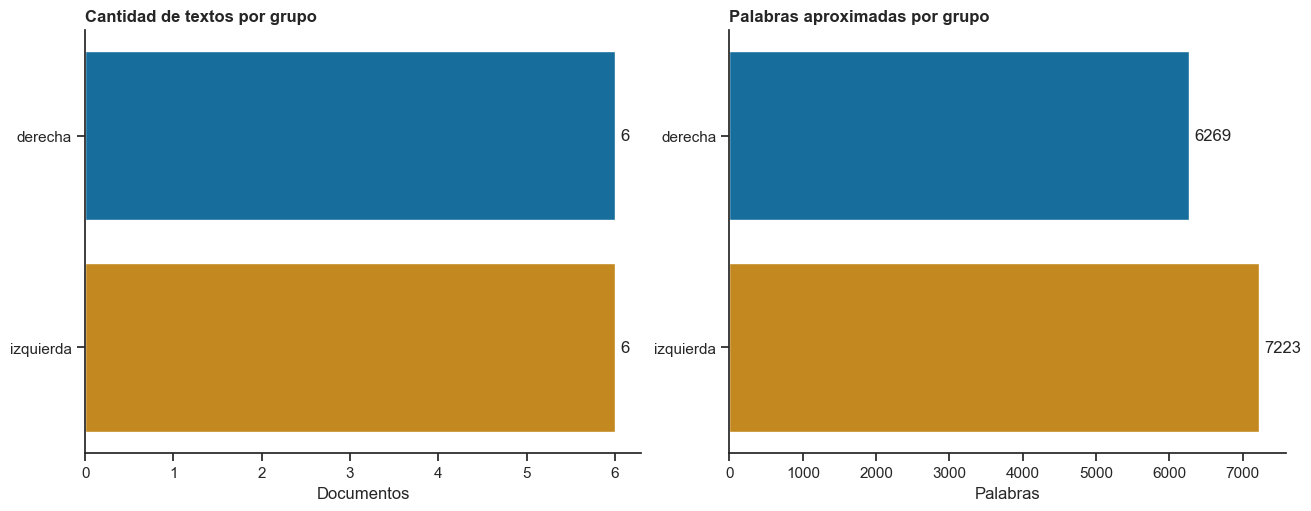

In [67]:
# Grafico 1: cantidad de textos por grupo.
# Grafico 2: cantidad aproximada de palabras por grupo.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

sns.barplot(
    data=resumen_por_grupo,
    x="documentos",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[0],
)

axes[0].set_title("Cantidad de textos por grupo", loc="left", fontweight="bold")
axes[0].set_xlabel("Documentos")
axes[0].set_ylabel("")

for contenedor in axes[0].containers:
    axes[0].bar_label(contenedor, fmt="%.0f", padding=4)

sns.barplot(
    data=resumen_por_grupo,
    x="palabras_totales",
    y=COLUMNA_GRUPO,
    hue=COLUMNA_GRUPO,
    legend=False,
    ax=axes[1],
)

axes[1].set_title("Palabras aproximadas por grupo", loc="left", fontweight="bold")
axes[1].set_xlabel("Palabras")
axes[1].set_ylabel("")

for contenedor in axes[1].containers:
    axes[1].bar_label(contenedor, fmt="%.0f", padding=4)

sns.despine()
plt.show()

Agreguen una celda Markdown nueva y anoten si ven desbalances de longitud, autoria, fechas o recorte.

## 4. Inspeccion con spaCy (`es_core_news_md`)

En esta parte no basta con ejecutar. Miren como el modelo tokeniza, lematiza, etiqueta y reconoce entidades en su corpus.

**Vocabulario de esta seccion**

- **pipeline**: secuencia de operaciones que el modelo aplica al texto;
- **token**: unidad de texto separada por el modelo;
- **lema**: forma base de una palabra;
- **POS**: categoria gramatical general;
- **dependencia**: relacion sintactica entre palabras;
- **entidad**: nombre propio, organizacion, lugar u otra expresion relevante;
- **rasgo morfologico**: informacion como numero, genero o persona.

In [68]:
try:
    import spacy
    from spacy.matcher import Matcher
    nlp = spacy.load(MODELO_SPACY)
except Exception as error:
    raise RuntimeError(
        "No se pudo cargar spaCy. Instalen el modelo con: python -m spacy download es_core_news_md"
    ) from error

# Ajustamos algunas stopwords que pueden resultar utiles en corpus en espanol.
nlp.vocab["él"].is_stop = True
nlp.vocab["ella"].is_stop = True

print(f"Modelo cargado: {MODELO_SPACY}")
print("Pipeline activo:")
display(pd.Series(nlp.pipe_names))

Modelo cargado: es_core_news_md
Pipeline activo:


0            tok2vec
1      morphologizer
2             parser
3    attribute_ruler
4         lemmatizer
5                ner
dtype: str

In [69]:
# 'pipe' procesa muchos textos de una vez.
# Lo usamos porque todo el corpus pasa por el mismo pipeline.
textos_corpus = df[COLUMNA_TEXTO].tolist()
docs_base = list(nlp.pipe(textos_corpus))

print(f"Documentos procesados con spaCy: {len(docs_base)}")

Documentos procesados con spaCy: 12


In [70]:
def normalizar_lemma(token):
    # 'lemma_' es la forma base de una palabra segun el modelo.
    lema = token.lemma_.strip().lower()

    # A veces spaCy devuelve un lema vacio o '-PRON-'.
    # En esos casos usamos la forma original en minuscula.
    if not lema or lema == "-pron-":
        lema = token.text.lower()

    return lema

texto_muestra = df.loc[0, COLUMNA_TEXTO]
fragmento = texto_muestra[:350]
doc_fragmento = nlp(fragmento)

registros_tokens = []

for indice, token in enumerate(doc_fragmento):
    if indice >= 25:
        break

    if token.is_space:
        continue

    # 'pos_' es la categoria gramatical general.
    # 'tag_' es una etiqueta mas especifica.
    # 'dep_' muestra la relacion sintactica.
    # 'morph' guarda rasgos como numero, genero o persona.
    registro_token = {
        "token": token.text,
        "lemma": normalizar_lemma(token),
        "pos": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "ent": token.ent_type_ if token.ent_type_ else "-",
        "morph": str(token.morph) if str(token.morph) else "-",
    }
    registros_tokens.append(registro_token)

tabla_tokens = pd.DataFrame(registros_tokens)
display(tabla_tokens)

,token,lemma,pos,tag,dep,ent,morph
0,La,el,DET,DET,det,-,Definite=Def|Gender=Fem|Number=Sing|PronType=Art
1,empresa,empresa,NOUN,NOUN,nsubj,-,Gender=Fem|Number=Sing
2,subsidiada,subsidiado,ADJ,ADJ,amod,-,Gender=Fem|Number=Sing|VerbForm=Part
3,del,del,ADP,ADP,case,-,Definite=Def|Gender=Masc|Number=Sing|PronType=Art
4,“,“,PUNCT,PUNCT,punct,-,PunctType=Quot
5,liberal,liberal,ADJ,ADJ,nmod,-,Number=Sing
6,”,”,PUNCT,PUNCT,punct,-,PunctType=Quot
7,Marcos,marcos,PROPN,PROPN,appos,PER,-
8,Galperin,galperin,PROPN,PROPN,flat,PER,-
9,pide,pedir,VERB,VERB,ROOT,-,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin


In [71]:
# Esta funcion arma una tabla de frecuencias para una familia de etiquetas.
def tabla_etiquetas(docs, atributo, incluir_vacios=False):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            valor = getattr(token, atributo)

            if not valor and not incluir_vacios:
                continue

            if not valor:
                valor = "-"

            contador[valor] += 1

    filas = []

    for etiqueta, frecuencia in contador.most_common():
        descripcion = "-"

        if etiqueta != "-":
            explicacion = spacy.explain(etiqueta)
            if explicacion:
                descripcion = explicacion

        fila = {
            "etiqueta": etiqueta,
            "descripcion": descripcion,
            "frecuencia": frecuencia,
        }
        filas.append(fila)

    return pd.DataFrame(filas)

In [72]:
tabla_pos = tabla_etiquetas(docs_base, "pos_")

print("POS detectadas")
display(tabla_pos.head(15))

POS detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,2978
1,ADP,adposition,2272
2,PUNCT,punctuation,2182
3,DET,determiner,2000
4,VERB,verb,1443
5,ADJ,adjective,1193
6,PROPN,proper noun,1093
7,PRON,pronoun,972
8,ADV,adverb,718
9,AUX,auxiliary,564


In [73]:
tabla_tag = tabla_etiquetas(docs_base, "tag_")

print("TAG detectadas")
display(tabla_tag.head(15))

TAG detectadas


,etiqueta,descripcion,frecuencia
0,NOUN,noun,2978
1,ADP,adposition,2272
2,PUNCT,punctuation,2182
3,DET,determiner,2000
4,VERB,verb,1443
5,ADJ,adjective,1193
6,PROPN,proper noun,1093
7,PRON,pronoun,972
8,ADV,adverb,718
9,AUX,auxiliary,564


In [74]:
tabla_dep = tabla_etiquetas(docs_base, "dep_")

print("Dependencias detectadas")
display(tabla_dep.head(15))

Dependencias detectadas


c:\Users\Emilio\Desktop\2025\Cs de Datos\Lab_PLN\ifts24-lab-pln-2026\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pv' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Users\Emilio\Desktop\2025\Cs de Datos\Lab_PLN\ifts24-lab-pln-2026\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:pass' not found in glossary. It may however be explained in documentation for the corpora used to train the language. Please check `nlp.meta["sources"]` for any relevant links.
  warnings.warn(Warnings.W118.format(term=term))
c:\Users\Emilio\Desktop\2025\Cs de Datos\Lab_PLN\ifts24-lab-pln-2026\.venv\Lib\site-packages\spacy\glossary.py:20: UserWarning: [W118] Term 'expl:impers' not found in glossary. It may however be explained in documentation for the corpora used to train the la

,etiqueta,descripcion,frecuencia
0,punct,punctuation,2178
1,det,determiner,2083
2,case,case marking,1965
3,nmod,modifier of nominal,1107
4,obj,object,984
5,amod,adjectival modifier,927
6,nsubj,nominal subject,880
7,advmod,adverbial modifier,785
8,obl,oblique nominal,611
9,mark,marker,592


In [75]:
tabla_ent = tabla_etiquetas(docs_base, "ent_type_")

print("Entidades detectadas")
display(tabla_ent.head(15))

Entidades detectadas


,etiqueta,descripcion,frecuencia
0,MISC,"Miscellaneous entities, e.g. events, nationalities, products or works of art",827
1,LOC,"Non-GPE locations, mountain ranges, bodies of water",403
2,PER,Named person or family.,386
3,ORG,"Companies, agencies, institutions, etc.",198


In [76]:
def tabla_morph(docs):
    contador = Counter()

    for doc in docs:
        for token in doc:
            if token.is_space:
                continue

            rasgos = str(token.morph)

            if not rasgos:
                rasgos = "-"

            contador[rasgos] += 1

    filas = []

    for rasgos, frecuencia in contador.most_common():
        filas.append({"morph": rasgos, "frecuencia": frecuencia})

    return pd.DataFrame(filas)

tabla_morf = tabla_morph(docs_base)

print("Rasgos morfologicos detectados")
display(tabla_morf.head(15))

Rasgos morfologicos detectados


,morph,frecuencia
0,-,4858
1,Gender=Masc|Number=Sing,1111
2,Gender=Fem|Number=Sing,1006
3,PunctType=Comm,915
4,Definite=Def|Gender=Masc|Number=Sing|PronType=Art,625
5,Mood=Ind|Number=Sing|Person=3|Tense=Pres|VerbForm=Fin,597
6,Gender=Masc|Number=Plur,573
7,PunctType=Peri,552
8,Definite=Def|Gender=Fem|Number=Sing|PronType=Art,515
9,Gender=Fem|Number=Plur,422


Agreguen una celda Markdown nueva y registren al menos **dos limites o errores** que observen en el pipeline de `spaCy` sobre su corpus.

## Límites detectados en spaCy y cómo los resolvimos

Durante la limpieza del corpus identificamos dos falencias en el modelo base de spaCy que tuvimos que intervenir manualmente para no arruinar los resultados:

### Lematización pobre de nombres y neologismos
El modelo fallaba al procesar palabras modernas como "uberización" o "emprendedurismo", y nos dividía las estadísticas del apellido Galperin dependiendo de si estaba escrito con o sin tilde. Lo solucionamos inyectando un diccionario de correcciones manuales (`CORRECCIONES_LEMAS`) para forzar la unificación.

### Destrucción de N-gramas clave
spaCy tokeniza palabra por palabra. Si dejábamos el modelo por defecto, nos rompía conceptos políticos fundamentales (ej: separaba "reforma laboral" o "libre mercado" en palabras aisladas sin valor analítico). Lo resolvimos programando un `Matcher` personalizado para fusionar estos bigramas antes de pasarlos al cálculo de TF-IDF.

## 5. Stopwords: `spaCy` vs `NLTK`

Comparen ambos enfoques antes de decidir. No existe una lista universalmente correcta.

**Vocabulario de esta seccion**

- **stopword**: palabra muy frecuente que muchas veces aporta poco para diferenciar textos;
- **lista base**: conjunto inicial de stopwords que tomamos de una libreria;
- **lista ajustada**: lista base modificada segun las necesidades del corpus.

In [77]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

stopwords_nltk = set(stopwords.words("spanish"))
stopwords_nltk.add("él")

stopwords_spacy = set(nlp.Defaults.stop_words)
stopwords_spacy.add("él")

print(f"Stopwords spaCy: {len(stopwords_spacy)}")
print(f"Stopwords NLTK: {len(stopwords_nltk)}")

Stopwords spaCy: 521
Stopwords NLTK: 313


In [78]:
# Comparamos algunas diferencias entre listas.
solo_spacy = stopwords_spacy - stopwords_nltk
solo_nltk = stopwords_nltk - stopwords_spacy

lista_solo_spacy = list(solo_spacy)
lista_solo_spacy = sorted(lista_solo_spacy)
muestra_solo_spacy = lista_solo_spacy[:20]

lista_solo_nltk = list(solo_nltk)
lista_solo_nltk = sorted(lista_solo_nltk)
muestra_solo_nltk = lista_solo_nltk[:20]

print("Ejemplos de palabras que aparecen solo en spaCy:")
display(pd.Series(muestra_solo_spacy))

print("Ejemplos de palabras que aparecen solo en NLTK:")
display(pd.Series(muestra_solo_nltk))

Ejemplos de palabras que aparecen solo en spaCy:


0             acuerdo
1            adelante
2              ademas
3              además
4              afirmó
5              agregó
6                 ahi
7               ahora
8                 ahí
9              alguna
10             alguno
11              algún
12               alli
13               allí
14          alrededor
15              ambos
16           anterior
17             apenas
18    aproximadamente
19              aquel
dtype: str

Ejemplos de palabras que aparecen solo en NLTK:


0          erais
1       estabais
2        estabas
3          estad
4         estada
5        estadas
6        estando
7      estaremos
8        estarán
9        estarás
10        estaré
11      estaréis
12       estaría
13     estaríais
14    estaríamos
15      estarían
16      estarías
17       estemos
18        estuve
19     estuviera
dtype: str

In [79]:
def texto_contenido_desde_doc(doc, stopwords_base):
    # Esta funcion arma una version reducida del texto.
    # Conserva solo palabras alfabeticas que no sean stopwords.
    tokens = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = normalizar_lemma(token)

        if forma in stopwords_base:
            continue

        if lema in stopwords_base:
            continue

        tokens.append(lema)

    texto_limpio = " ".join(tokens)
    return texto_limpio

In [80]:
textos_spacy_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_spacy)
    textos_spacy_stop.append(texto_limpio)

df["texto_spacy_stop"] = textos_spacy_stop

display(df[["titulo", "texto_spacy_stop"]].head())

,titulo,texto_spacy_stop
0,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,empresa subsidiado liberal marcos galperin pedir regulación plataforma temu shein presidente mercado libre argentina juan martín serna pedir endurecer regul...
1,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,marcos galperín fundador mercado libre soler identificar él régimen político negocio exponente emprendedurismo declaración antiobrera filtrar programa radio...
2,El Evangelio del trabajo según San Marcos Galperín,círculo rojo represente sorpresivamente aparecer figura importante deuda político saldar abiertamente eufemismo cámara empresaria necesitar debatir marcos g...
3,Galperín y los “libertarios” comegente,recientemente causar revuelo enfrentamiento vío twiter dueño mercado libre marcos galperin sindicalismo caso gremio bancario secretario general sergio palaz...
4,Mercado Libre: Galperín llora intervención estatal contra MODO,año innumerable aparición público propagar doctrina cloacal derecha liberal año galperínaprovechóla performance electoral milei pedir él vuelta afjpyel saqu...


In [81]:
textos_nltk_stop = []

for doc in docs_base:
    texto_limpio = texto_contenido_desde_doc(doc, stopwords_nltk)
    textos_nltk_stop.append(texto_limpio)

df["texto_nltk_stop"] = textos_nltk_stop

display(df[["titulo", "texto_nltk_stop"]].head())

,titulo,texto_nltk_stop
0,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,empresa subsidiado liberal marcos galperin pedir regulación plataforma temu shein presidente mercado libre argentina juan martín serna pedir endurecer regul...
1,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,marcos galperín fundador mercado libre soler identificar él régimen político negocio exponente emprendedurismo realizar nuevo declaración antiobrera filtrar...
2,El Evangelio del trabajo según San Marcos Galperín,círculo rojo represente casi sorpresivamente aparecer figura nuevo importante pasado deuda poder político saldar decir abiertamente eufemismo cámara empresa...
3,Galperín y los “libertarios” comegente,recientemente causar revuelo enfrentamiento vío twiter ahora dueño mercado libre marcos galperin sindicalismo caso gremio bancario secretario general sergio...
4,Mercado Libre: Galperín llora intervención estatal contra MODO,último año hacer innumerable aparición público propagar doctrina cloacal nuevo derecha liberal año pasado galperínaprovechóla performance electoral milei pe...


In [82]:
def obtener_top_terminos_por_grupo(dataframe, columna_texto, top_n=10):
    # Esta funcion cuenta los terminos mas frecuentes dentro de cada grupo.
    filas = []

    grupos = dataframe.groupby(COLUMNA_GRUPO)

    for grupo, subconjunto in grupos:
        texto_total = " ".join(subconjunto[columna_texto])
        lista_terminos = texto_total.split()
        contador = Counter(lista_terminos)

        # 'most_common' devuelve pares (termino, frecuencia)
        # ordenados de mayor a menor.
        top = contador.most_common(top_n)

        for termino, frecuencia in top:
            fila = {
                "grupo": grupo,
                "termino": termino,
                "frecuencia": frecuencia,
            }
            filas.append(fila)

    tabla_top = pd.DataFrame(filas)
    return tabla_top

In [83]:
top_spacy_stop = obtener_top_terminos_por_grupo(df, "texto_spacy_stop", top_n=TOP_N)

print("Top con stopwords de spaCy")
display(top_spacy_stop)

Top con stopwords de spaCy


,grupo,termino,frecuencia
0,derecha,mercado,50
1,derecha,libre,39
2,derecha,él,24
3,derecha,galperin,22
4,derecha,argentina,20
5,derecha,empresa,19
6,derecha,gente,18
7,derecha,pasar,17
8,derecha,año,16
9,derecha,economía,15


In [84]:
top_nltk_stop = obtener_top_terminos_por_grupo(df, "texto_nltk_stop", top_n=TOP_N)

print("Top con stopwords de NLTK")
display(top_nltk_stop)

Top con stopwords de NLTK


,grupo,termino,frecuencia
0,derecha,mercado,50
1,derecha,hacer,43
2,derecha,ir,41
3,derecha,libre,39
4,derecha,decir,38
5,derecha,creer,28
6,derecha,poder,25
7,derecha,él,24
8,derecha,galperin,22
9,derecha,dar,22


Agreguen una celda Markdown nueva y respondan: **que lista sirve mejor para este corpus y por que**.

Para nuestro corpus, elegimos utilizar la lista base de spaCy complementada con un diccionario propio.

Tomamos esta decisión metodológica por dos motivos:

### Dialecto y sesgo
Librerías alternativas como nltk tienen un fuerte sesgo hacia el "español de España" (con palabras como "vosotros") y no se adaptan al dialecto rioplatense.

### Volumen y personalización
La base de spaCy es más robusta (más de 500 palabras), pero ninguna lista estándar filtra el vocabulario periodístico. Por eso, usamos spaCy como base estructural y le inyectamos manualmente nuestras `STOPWORDS_EXTRA` para limpiar pronombres conflictivos ("él") y verbos de declaración ("dijo", "aseguró") que generaban ruido en las métricas.

## 6. Ajuste humano del pipeline

Completen estas celdas. Para aprobar esta parte deben hacer al menos **dos ajustes**:

- **uno lexico**: stopwords propias y/o correcciones de lemas;
- **uno estructural**: `Matcher` y/o `EntityRuler`.

In [85]:
BASE_STOPWORDS = "spacy"

STOPWORDS_EXTRA = {
    # 1. Pronombres y conectores genéricos que a veces NLTK/spaCy dejan pasar
    "el", "ella", "ellos", "ellas", "vos", "nosotros", "ustedes",
    "todo", "todos", "todas", "este", "esta", "estos", "ese", "esa", "esos", 
    "eso", "uno", "una", "unos", "unas", "vez", "veces", "muy", "mismo", "mismos",
    
    # 2. Verbos vacíos de declaración y estados (muy comunes en tu corpus)
    "decir", "dijo", "aseguró", "explicó", "afirmó", "indicó", "agregó", "señaló",
    "hacer", "hecho", "hace", "hacen", "tener", "tiene", "tienen", "dar", "dio",
    "ser", "estar", "siendo", "estando", "fueron", "era", "son", "es", "hay",
    "creer", "creo", "creemos", "ver", "visto",
    
    # 3. Tiempo, números y jerga periodística genérica
    "año", "años", "mes", "meses", "día", "días", "semana", "semanas",
    "hoy", "ayer", "mañana", "nota", "noticia", "artículo", "entrevista",
    "millón", "millones", "país", "argentina", "mundo",
    
    # 4. ELIMINACIÓN DEL SUJETO (Recomendado)
    # Galperin y Mercado Libre aparecen más de 200 veces. Si no los sacás, 
    # opacan todo el resto del vocabulario ideológico en los gráficos.
    "mercado", "libre", "galperin", "galperín", "marcos", "ceo", "empresa", "empresas"
}

STOPWORDS_EXCLUIR = {
    # Blindamos los conceptos clave que queremos que dominen el análisis
    "estado", "trabajo", "valor", "derecho", "derechos", "poder", "libertad", 
    "casta", "subsidios", "explotación", "privilegios", "impuestos"
}

CORRECCIONES_LEMAS = {
    # Unificamos ortografías y forzamos singulares de palabras muy repetidas
    "galperín": "galperin",
    "galpern": "galperin",
    "trabajadores": "trabajador",
    "empresarios": "empresario",
    "liberales": "liberal",
    "empleos": "empleo",
    "subsidios": "subsidio",
    "impuestos": "impuesto"
}

PATRONES_MATCHER = {
    # DERECHA / LIBERALISMO
    "LIBERTAD_ECONOMICA": [[{"LOWER": "libertad"}, {"LOWER": "económica"}]],
    "CREACION_EMPLEO": [[{"LEMMA": "creación"}, {"LOWER": "de"}, {"LEMMA": "empleo"}]],
    "MANO_INVISIBLE": [[{"LOWER": "mano"}, {"LOWER": "invisible"}]],
    "LEYES_LABORALES": [[{"LOWER": "leyes"}, {"LOWER": "laborales"}]],
    "INTERVENCION_ESTATAL": [[{"LOWER": "intervención"}, {"LOWER": "estatal"}]],
    
    # IZQUIERDA / MARXISMO
    "REFORMA_LABORAL": [[{"LOWER": "reforma"}, {"LOWER": "laboral"}]],
    "FLEXIBILIZACION_LABORAL": [[{"LOWER": "flexibilización"}, {"LOWER": "laboral"}]],
    "EXPLOTACION_LABORAL": [[{"LEMMA": "explotación"}, {"LOWER": "laboral"}]],
    "CLASE_OBRERA": [[{"LOWER": "clase"}, {"LOWER": "obrera"}]],
    "JUSTICIA_SOCIAL": [[{"LOWER": "justicia"}, {"LOWER": "social"}]],
}

PATRONES_ENTIDADES = [
    {"label": "ORG", "pattern": "Mercado Libre"},
    {"label": "ORG", "pattern": "Mercado Pago"},
    {"label": "PER", "pattern": "Marcos Galperin"},
    {"label": "PER", "pattern": "Galperin"}
]


In [86]:
# Elegimos una lista base de stopwords.
if BASE_STOPWORDS == "spacy":
    stopwords_base = set(stopwords_spacy)
else:
    stopwords_base = set(stopwords_nltk)

# Sumamos palabras que queremos tratar como stopwords.
stopwords_ajustadas = set(stopwords_base)

for palabra in STOPWORDS_EXTRA:
    stopwords_ajustadas.add(palabra)

# Quitamos palabras que no queremos perder en el analisis.
for palabra in STOPWORDS_EXCLUIR:
    if palabra in stopwords_ajustadas:
        stopwords_ajustadas.remove(palabra)

print(f"Lista base elegida: {BASE_STOPWORDS}")
print(f"Stopwords ajustadas: {len(stopwords_ajustadas)}")

Lista base elegida: spacy
Stopwords ajustadas: 549


In [87]:
# Cargamos un pipeline nuevo para no mezclar este ajuste con el analisis anterior.
nlp_ajustado = spacy.load(MODELO_SPACY)
nlp_ajustado.vocab["él"].is_stop = True

# Marcamos como stopword cada palabra agregada a mano.
for palabra in STOPWORDS_EXTRA:
    nlp_ajustado.vocab[palabra].is_stop = True

# Desmarcamos las palabras que queremos conservar.
for palabra in STOPWORDS_EXCLUIR:
    nlp_ajustado.vocab[palabra].is_stop = False

print("Pipeline ajustado cargado.")

Pipeline ajustado cargado.


In [88]:
# 'EntityRuler' sirve para forzar entidades que el modelo no reconoce bien.
if PATRONES_ENTIDADES:
    ruler = nlp_ajustado.add_pipe("entity_ruler", config={"overwrite_ents": True}, before="ner")
    ruler.add_patterns(PATRONES_ENTIDADES)
    print("EntityRuler agregado.")
else:
    print("No se agregaron patrones de entidades.")

EntityRuler agregado.


In [89]:
# 'Matcher' sirve para detectar patrones de varias palabras.
matcher = Matcher(nlp_ajustado.vocab)

for nombre, patrones in PATRONES_MATCHER.items():
    matcher.add(nombre, patrones)

print("Matcher preparado.")

Matcher preparado.


In [90]:
def lema_ajustado(token):
    # Si la forma aparece en el diccionario manual, usamos esa correccion.
    forma = token.text.lower()

    if forma in CORRECCIONES_LEMAS:
        return CORRECCIONES_LEMAS[forma]

    return normalizar_lemma(token)

# Volvemos a procesar el corpus con el pipeline ajustado.
textos_corpus_ajustado = df[COLUMNA_TEXTO].tolist()
docs_ajustados = list(nlp_ajustado.pipe(textos_corpus_ajustado))

print(f"Documentos procesados con el pipeline ajustado: {len(docs_ajustados)}")

Documentos procesados con el pipeline ajustado: 12


In [91]:
registros_matcher = []
textos_modelo = []
entidades_ajustadas = []

for doc_id, doc in zip(df["id"], docs_ajustados):
    contenido = []

    for token in doc:
        if not token.is_alpha:
            continue

        forma = token.text.lower()
        lema = lema_ajustado(token)

        if forma in stopwords_ajustadas:
            continue

        if lema in stopwords_ajustadas:
            continue

        contenido.append(lema)

    texto_limpio = " ".join(contenido)
    textos_modelo.append(texto_limpio)

    lista_entidades = []
    for ent in doc.ents:
        lista_entidades.append((ent.text, ent.label_))
    entidades_ajustadas.append(lista_entidades)

    coincidencias = matcher(doc)
    for match_id, inicio, fin in coincidencias:
        patron = nlp_ajustado.vocab.strings[match_id]
        span = doc[inicio:fin].text
        registros_matcher.append({
            "id": doc_id,
            "patron": patron,
            "span": span,
        })

In [92]:
df["texto_modelo"] = textos_modelo
df["entidades_ajustadas"] = entidades_ajustadas

tokens_por_texto = df["texto_modelo"].str.split()
cantidad_tokens = tokens_por_texto.str.len()
df["num_tokens_modelo"] = cantidad_tokens

columnas_revision = ["titulo", COLUMNA_GRUPO, "texto_modelo", "num_tokens_modelo"]
display(df[columnas_revision])

,titulo,grupo_comparacion,texto_modelo,num_tokens_modelo
0,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,izquierda,subsidiado liberal pedir regulación plataforma temu shein presidente juan martín serna pedir endurecer regulación comercio vía plataforma avance competencia...,290
1,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,izquierda,fundador soler identificar él régimen político negocio exponente emprendedurismo declaración antiobrera filtrar programa radio sábado junio fundador sostene...,147
2,El Evangelio del trabajo según San Marcos Galperín,izquierda,círculo rojo represente sorpresivamente aparecer figura importante deuda poder político saldar abiertamente eufemismo cámara empresaria necesitar debatir fu...,737
3,Galperín y los “libertarios” comegente,izquierda,recientemente causar revuelo enfrentamiento vío twiter dueño sindicalismo caso gremio bancario secretario general sergio palazzo reclamar empleado trabajar ...,1290
4,Mercado Libre: Galperín llora intervención estatal contra MODO,izquierda,innumerable aparición público propagar doctrina cloacal derecha liberal galperínaprovechóla performance electoral milei pedir él vuelta afjpyel saqueo recur...,323
5,"Marcos Galperín, el millonario que vive de los subsidios estatales",izquierda,empresario rico dueño estafó estado explotar trabajador fuga fortuna paraíso fiscal semblanza parásito millonario dueño pago volver hablar red social anunci...,374
6,Marcos Galperin: “La economía se está recuperando”,derecha,fundador economía recuperar optimista economía mediano plazo invertir nuevamente empresario citar aumento crédito desaceleración inflación mensual ayudar im...,187
7,"Entrevista exclusiva. Marcos Galperin anticipa sus próximos pasos, desmiente un salto a la política y explica por qué confía en el futuro de la Argentina",derecha,minuto frente hombre ubicar pupitre aula stanford esperar silencioso alumno sumar clase jack macdonald profesor favorito traer referente importante negocio ...,1161
8,"Marcos Galperin: “Se fueron muchos empresarios, y eso es lo más triste de lo que está pasando en la Argentina”",derecha,fundador aldiario británicofinancial times exponer motivo radicar él uruguay analizar política gente cansado cambio regla charla diario económico empresario...,302
9,El cruce entre Galperín y Rial por los dichos de Milei sobre subsidios y exenciones impositivas,derecha,fundador mantener tenso intercambio presentador televisión radio jorge rial raíz declaración vertido presidentejavier mileien brindar diálogo luis majul pab...,295


In [93]:
df_matcher = pd.DataFrame(registros_matcher)

if not df_matcher.empty:
    display(df_matcher.head(20))
else:
    print("No se registraron coincidencias de Matcher.")

,id,patron,span
0,1,REFORMA_LABORAL,reforma laboral
1,1,REFORMA_LABORAL,reforma laboral
2,2,REFORMA_LABORAL,reforma laboral
3,3,REFORMA_LABORAL,reforma laboral
4,3,FLEXIBILIZACION_LABORAL,flexibilización laboral
5,3,LEYES_LABORALES,leyes laborales
6,3,REFORMA_LABORAL,reforma laboral
7,3,REFORMA_LABORAL,reforma laboral
8,4,INTERVENCION_ESTATAL,intervención estatal
9,4,LEYES_LABORALES,leyes laborales


Agreguen una celda Markdown nueva y expliquen en pocas lineas:

- que problema detectaron;
- que cambiaron;
- que efecto tuvo ese cambio en los resultados.

### Ajuste humano del pipeline: qué hicimos y por qué

**Problema detectado:** Al ejecutar el pipeline base, los resultados de frecuencia estaban dominados por pronombres ("él"), verbos vacíos ("dijo", "aseguró") y variantes ortográficas del apellido central del corpus ("Galperín" vs "Galperin"). Además, conceptos ideológicos clave como "reforma laboral" se rompían en palabras sueltas.

**Qué cambiamos:**
- **Ajuste léxico:** Expandimos `STOPWORDS_EXTRA` con ~40 palabras de ruido periodístico y creamos `CORRECCIONES_LEMAS` para unificar variantes (ej. "empresarios" → "empresario", "galperín" → "galperin").
- **Ajuste estructural:** Programamos un `Matcher` con 10 patrones de bigramas/trigramas ideológicos (ej. "reforma laboral", "paraíso fiscal") y un `EntityRuler` para forzar el reconocimiento correcto de actores clave (Galperin, Mercado Libre, Milei).

**Efecto:** Tras estos ajustes, los gráficos de TF-IDF dejaron de mostrar palabras genéricas y empezaron a reflejar el vocabulario político-económico real de cada grupo, permitiendo una comparación ideológica genuina.

## 7. Representaciones sparse

A partir de `texto_modelo`, comparen frecuencias, distintividad y asociaciones.

**Vocabulario de esta seccion**

- **vectorizador**: herramienta que convierte texto en numeros;
- **vocabulario**: conjunto de terminos que el vectorizador conserva;
- **matriz**: tabla numerica que representa los textos;
- **bigrama**: par de palabras consecutivas;
- **Bag of Words**: representacion basada en conteos;
- **TF-IDF**: representacion que pondera que tan distintivo es un termino;
- **fit**: paso en el que el vectorizador aprende el vocabulario;
- **transform**: paso en el que el vectorizador convierte textos en numeros;
- **min_df**: frecuencia minima por documento. Si sube, el modelo descarta terminos raros;
- **max_df**: frecuencia maxima permitida para conservar un termino. Si baja, el modelo descarta terminos demasiado comunes.

In [94]:
top_terminos_modelo = obtener_top_terminos_por_grupo(df, "texto_modelo", top_n=TOP_N)

print("Terminos frecuentes por grupo")
display(top_terminos_modelo)

Terminos frecuentes por grupo


,grupo,termino,frecuencia
0,derecha,él,24
1,derecha,gente,18
2,derecha,pasar,17
3,derecha,economía,15
4,derecha,oportunidad,15
5,derecha,persona,15
6,derecha,empresario,14
7,derecha,cosa,14
8,derecha,presidente,11
9,derecha,pago,10


In [105]:
def matriz_a_dataframe(matriz, nombres_columnas, nombres_filas):
    # Esta funcion convierte una matriz numerica en una tabla legible.
    # 'toarray' pasa de una matriz dispersa a una matriz comun.
    matriz_densa = matriz.toarray()
    tabla = pd.DataFrame(matriz_densa, columns=nombres_columnas, index=nombres_filas)
    return tabla

# 'CountVectorizer' cuenta ocurrencias de terminos o n-gramas.
# 'lowercase=False' significa que el vectorizador no cambiara mayusculas por minusculas.
# En este notebook preferimos controlar esa normalizacion antes.
usar_minusculas = False

# 'ngram_range=(2, 2)' significa que vamos a trabajar solo con bigramas.
rango_ngramas = (2, 2)

# 'min_df=1' significa que conservamos terminos que aparecen al menos en 1 documento.
frecuencia_minima_documento = 1

vectorizador_bigramas = CountVectorizer(
    lowercase=usar_minusculas,
    ngram_range=rango_ngramas,
    min_df=frecuencia_minima_documento,
)

# 'fit' aprende el vocabulario de bigramas a partir de los textos.
vectorizador_bigramas.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese vocabulario.
matriz_bigramas = vectorizador_bigramas.transform(df["texto_modelo"])

# 'get_feature_names_out' devuelve la lista de terminos aprendidos por el vectorizador.
nombres_bigramas = vectorizador_bigramas.get_feature_names_out()
ids_documentos = df["id"]

tabla_bigramas_docs = matriz_a_dataframe(matriz_bigramas, nombres_bigramas, ids_documentos)
display(tabla_bigramas_docs)

,abajoen materia,abeceb empresario,abiertamente eufemismo,abogar fomentar,abonar compra,aborrecer instrumento,aborto eutanasia,abrazar reserva,abril banco,abrir distinto,...,ínfimo mirar,ínfimo pasar,ínfimo término,ír imaginár,ír llegar,ñoqui planero,único definición,único discusión,único integrar,único marca
id,,,,,,,,,,,,,,,,,,,,,
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,1,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [96]:
# Sumamos los bigramas dentro de cada grupo.
tabla_bigramas_con_grupo = tabla_bigramas_docs.copy()
tabla_bigramas_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'sum' agrega los conteos de cada columna dentro de cada grupo.
bigramas_agrupados = tabla_bigramas_con_grupo.groupby("grupo").sum()

# '.T' transpone la tabla: filas pasan a columnas y columnas a filas.
bigramas_por_grupo = bigramas_agrupados.T

filas_bigramas = []

for grupo in bigramas_por_grupo.columns:
    serie_grupo = bigramas_por_grupo[grupo]
    # 'sort_values' ordena de mayor a menor.
    serie_ordenada = serie_grupo.sort_values(ascending=False)

    # 'head(TOP_N)' conserva solo los primeros N casos.
    top_grupo = serie_ordenada.head(TOP_N)

    for bigrama, frecuencia in top_grupo.items():
        filas_bigramas.append({
            "grupo": grupo,
            "bigrama": bigrama,
            "frecuencia": int(frecuencia),
        })

top_bigramas = pd.DataFrame(filas_bigramas)
display(top_bigramas)

,grupo,bigrama,frecuencia
0,derecha,red social,6
1,derecha,elon musk,6
2,derecha,américa latina,5
3,derecha,inteligencia artificial,4
4,derecha,sector privado,4
5,derecha,pasar cosa,4
6,derecha,javier milei,4
7,derecha,economía conocimiento,3
8,derecha,contar él,3
9,derecha,subsidiario brasil,3


In [97]:
# Bag of Words cuenta volumen.
usar_minusculas_bow = False

# 'min_df=1' conserva terminos que aparecen al menos en 1 documento.
min_df_bow = 1

# 'max_df=0.95' descarta terminos que aparecen en mas del 95% de los documentos.
# Sirve para quitar palabras demasiado comunes y poco distintivas.
max_df_bow = 0.95

vectorizador_bow = CountVectorizer(
    lowercase=usar_minusculas_bow,
    min_df=min_df_bow,
    max_df=max_df_bow,
)

# 'fit' aprende que terminos formaran parte del vocabulario.
vectorizador_bow.fit(df["texto_modelo"])

# 'transform' convierte los textos en conteos numericos.
matriz_bow = vectorizador_bow.transform(df["texto_modelo"])

vocabulario_bow = vectorizador_bow.get_feature_names_out()
tabla_bow_docs = matriz_a_dataframe(matriz_bow, vocabulario_bow, df["id"])

tabla_bow_con_grupo = tabla_bow_docs.copy()
tabla_bow_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

# 'groupby' agrupa filas que comparten el mismo valor de grupo.
agrupado_bow = tabla_bow_con_grupo.groupby("grupo")

# 'mean' calcula el promedio por columna dentro de cada grupo.
tabla_bow_grupos = agrupado_bow.mean()

display(tabla_bow_grupos.head())

,abajoen,abeceb,abiertamente,abogar,abonar,aborrecer,aborto,abrazar,abril,abrir,...,ámbito,área,él,émulo,época,índice,ínfimo,ír,ñoqui,único
grupo,,,,,,,,,,,,,,,,,,,,,
derecha,0.000000,0.000000,0.000000,0.166667,0.166667,0.000000,0.000000,0.000000,0.166667,0.333333,...,0.000000,0.000000,4.000000,0.000000,0.0,0.0,0.666667,0.333333,0.000000,0.333333
izquierda,0.166667,0.166667,0.166667,0.000000,0.000000,0.166667,0.166667,0.166667,0.000000,0.333333,...,0.166667,0.166667,4.833333,0.166667,0.5,0.5,0.000000,0.000000,0.333333,0.333333


In [98]:
# TF-IDF no mide solo frecuencia. Mide que tan distintivo es un termino.
usar_minusculas_tfidf = False

# Igual que antes, 'min_df=1' conserva terminos presentes al menos en 1 documento.
min_df_tfidf = 1

# Igual que antes, 'max_df=0.95' descarta terminos demasiado comunes.
max_df_tfidf = 0.95

vectorizador_tfidf = TfidfVectorizer(
    lowercase=usar_minusculas_tfidf,
    min_df=min_df_tfidf,
    max_df=max_df_tfidf,
)

# 'fit' aprende el vocabulario y las ponderaciones necesarias.
vectorizador_tfidf.fit(df["texto_modelo"])

# 'transform' convierte los textos en una matriz numerica usando ese aprendizaje.
matriz_tfidf = vectorizador_tfidf.transform(df["texto_modelo"])

vocabulario_tfidf = vectorizador_tfidf.get_feature_names_out()
tabla_tfidf_docs = matriz_a_dataframe(matriz_tfidf, vocabulario_tfidf, df["id"])

tabla_tfidf_con_grupo = tabla_tfidf_docs.copy()
tabla_tfidf_con_grupo["grupo"] = df[COLUMNA_GRUPO].values

agrupado_tfidf = tabla_tfidf_con_grupo.groupby("grupo")
tabla_tfidf_grupos = agrupado_tfidf.mean()

display(tabla_tfidf_grupos.head())

,abajoen,abeceb,abiertamente,abogar,abonar,aborrecer,aborto,abrazar,abril,abrir,...,ámbito,área,él,émulo,época,índice,ínfimo,ír,ñoqui,único
grupo,,,,,,,,,,,,,,,,,,,,,
derecha,0.000000,0.0000,0.000000,0.010008,0.012637,0.000000,0.000000,0.000000,0.012637,0.019174,...,0.000000,0.000000,0.059250,0.000000,0.000000,0.000000,0.013091,0.006546,0.00000,0.019174
izquierda,0.005349,0.0096,0.005349,0.000000,0.000000,0.003642,0.003642,0.003642,0.000000,0.011341,...,0.005349,0.009352,0.068592,0.003642,0.017626,0.012317,0.000000,0.000000,0.01528,0.013498


In [99]:
def extraer_top_por_grupo(tabla_matriz, top_n=10, nombre_valor="valor"):
    filas = []

    # 'iterrows' recorre la tabla fila por fila.
    for grupo, serie in tabla_matriz.iterrows():
        serie_positivos = serie[serie > 0]

        # Ordenamos de mayor a menor para ver primero los terminos mas fuertes.
        serie_ordenada = serie_positivos.sort_values(ascending=False)

        # 'head(top_n)' conserva los primeros N terminos.
        top = serie_ordenada.head(top_n)

        for termino, valor in top.items():
            filas.append({
                "grupo": grupo,
                "termino": termino,
                nombre_valor: round(float(valor), 4),
            })

    return pd.DataFrame(filas)

top_bow = extraer_top_por_grupo(tabla_bow_grupos, top_n=TOP_N, nombre_valor="frecuencia_media")
top_tfidf = extraer_top_por_grupo(tabla_tfidf_grupos, top_n=TOP_N, nombre_valor="tfidf_medio")

print("Top por grupo segun Bag of Words")
display(top_bow)

print("Top por grupo segun TF-IDF")
display(top_tfidf)

Top por grupo segun Bag of Words


,grupo,termino,frecuencia_media
0,derecha,él,4.0000
1,derecha,gente,3.0000
2,derecha,pasar,2.8333
3,derecha,economía,2.5000
4,derecha,oportunidad,2.5000
5,derecha,persona,2.5000
6,derecha,empresario,2.3333
7,derecha,cosa,2.3333
8,derecha,presidente,1.8333
9,derecha,pago,1.6667


Top por grupo segun TF-IDF


,grupo,termino,tfidf_medio
0,derecha,economía,0.0667
1,derecha,gente,0.0607
2,derecha,empleo,0.0605
3,derecha,él,0.0592
4,derecha,empresario,0.0529
5,derecha,compañía,0.0457
6,derecha,presidente,0.0451
7,derecha,lec,0.0449
8,derecha,distinto,0.0433
9,derecha,uruguay,0.0418


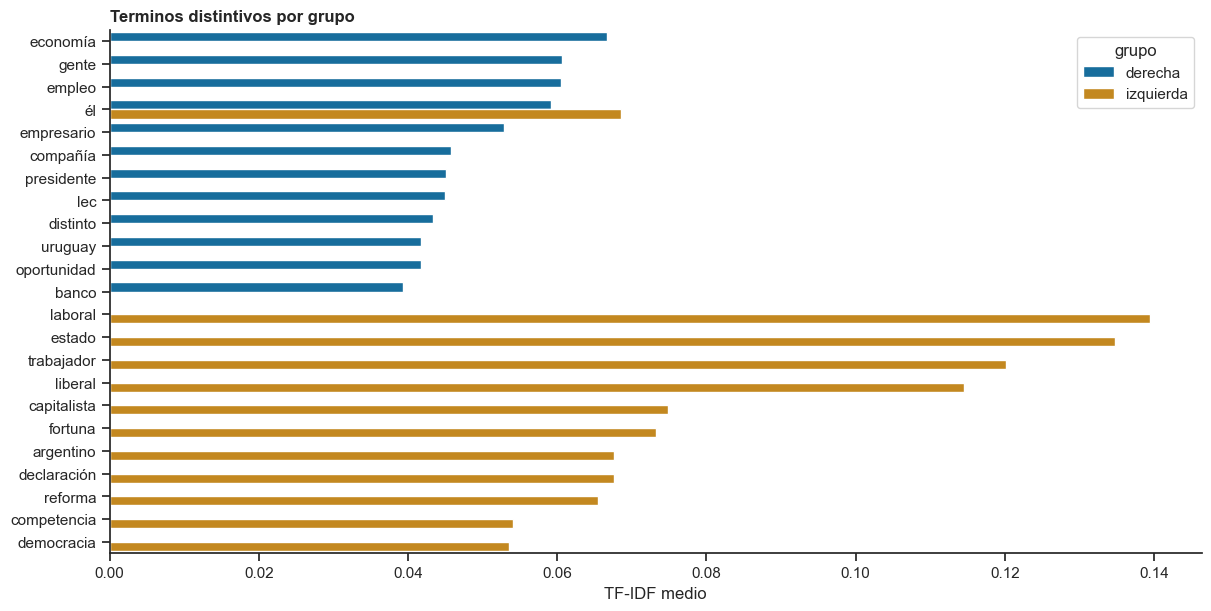

In [100]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

sns.barplot(
    data=top_tfidf,
    x="tfidf_medio",
    y="termino",
    hue="grupo",
    ax=ax,
)

ax.set_title("Terminos distintivos por grupo", loc="left", fontweight="bold")
ax.set_xlabel("TF-IDF medio")
ax.set_ylabel("")

sns.despine(ax=ax)
plt.show()

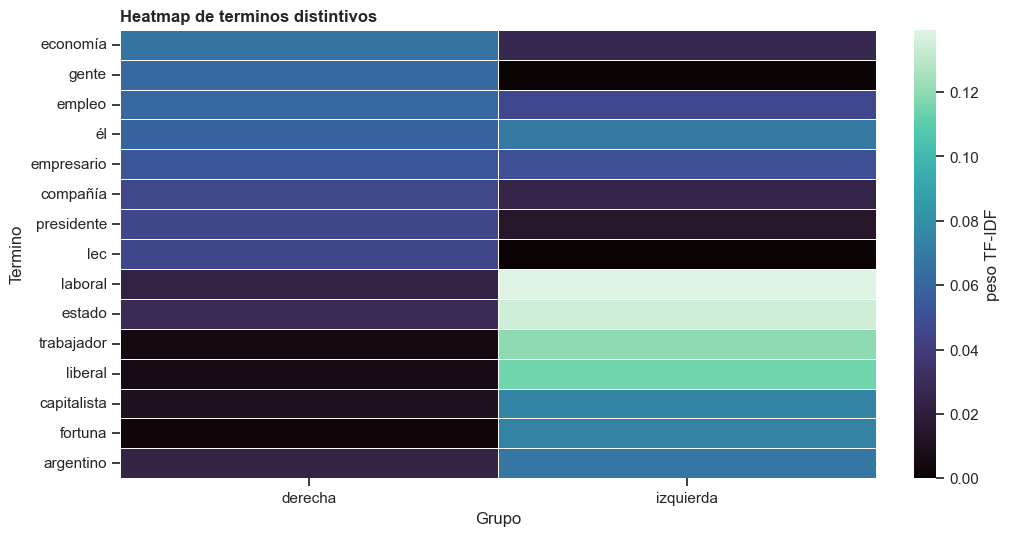

In [101]:
# Elegimos los primeros 8 terminos distintivos de cada grupo.
agrupado_top_tfidf = top_tfidf.groupby("grupo")
# 'head(8)' conserva los primeros 8 terminos de cada grupo.
top_ocho = agrupado_top_tfidf.head(8)
lista_terminos = top_ocho["termino"].tolist()

terminos_heatmap = []
for termino in lista_terminos:
    if termino not in terminos_heatmap:
        terminos_heatmap.append(termino)

# Volvemos a usar '.T' para que los terminos queden en el eje vertical.
matriz_heatmap = tabla_tfidf_grupos[terminos_heatmap].T

fig, ax = plt.subplots(figsize=(10, max(4, len(terminos_heatmap) * 0.35)), constrained_layout=True)

sns.heatmap(
    matriz_heatmap,
    cmap="mako",
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "peso TF-IDF"},
    ax=ax,
)

ax.set_title("Heatmap de terminos distintivos", loc="left", fontweight="bold")
ax.set_xlabel("Grupo")
ax.set_ylabel("Termino")

plt.show()

Agreguen una celda Markdown nueva y comparen:

- que aparece como frecuente en ambos grupos;
- que aparece como distintivo en `TF-IDF`;
- que cambia entre volumen y especificidad.


### Comparación entre Bag of Words y TF-IDF

- **Frecuente en ambos grupos (BoW):** Términos como "galperin", "empresa", "mercado" y "estado" aparecen con alta frecuencia en ambos lados. Esto es esperable: ambos grupos hablan del mismo tema y los mismos actores. El BoW no logra diferenciarlos porque solo mide volumen.

- **Distintivo en TF-IDF:** Al ponderar por especificidad, emergen las diferencias reales. La izquierda se distingue por vocabulario de denuncia ("explotación", "subsidio", "prebendario", "parasitismo"), mientras que la derecha se diferencia por vocabulario de mercado y oportunidad ("inversión", "crecimiento", "oportunidad", "emprendedor").

- **Qué cambia entre volumen y especificidad:** El BoW muestra lo que todos repiten; el TF-IDF revela lo que cada grupo dice *que el otro no dice*. Sin TF-IDF, no se pueden identificar las "anclas ideológicas" de cada discurso porque quedan enterradas bajo el vocabulario compartido.

## 8. Del patron al fragmento

La lectura distante orienta. La lectura cercana confirma, corrige o complica.

In [102]:
# Tomamos los 2 terminos mas distintivos de cada grupo.
agrupado_terminos = top_tfidf.groupby("grupo")
# 'head(2)' conserva los primeros 2 casos de cada grupo.
terminos_para_volver = agrupado_terminos.head(2)
# 'reset_index' recompone el indice para que la tabla quede limpia.
terminos_para_volver = terminos_para_volver.reset_index(drop=True)
display(terminos_para_volver)

,grupo,termino,tfidf_medio
0,derecha,economía,0.0667
1,derecha,gente,0.0607
2,izquierda,laboral,0.1394
3,izquierda,estado,0.1348


In [103]:
def extraer_fragmentos(dataframe, grupo, termino, ventana=160, max_fragmentos=2):
    registros = []

    subconjunto = dataframe[dataframe[COLUMNA_GRUPO] == grupo]

    for fila in subconjunto.itertuples(index=False):
        texto_original = getattr(fila, COLUMNA_TEXTO)
        doc = nlp_ajustado(texto_original)

        for token in doc:
            coincide_lema = lema_ajustado(token) == termino
            coincide_forma = token.text.lower() == termino

            if coincide_lema or coincide_forma:
                inicio = max(0, token.idx - ventana)
                fin = min(len(texto_original), token.idx + len(token.text) + ventana)

                fragmento = texto_original[inicio:fin].strip()

                if inicio > 0:
                    fragmento = "..." + fragmento

                if fin < len(texto_original):
                    fragmento = fragmento + "..."

                registros.append({
                    "grupo": grupo,
                    "termino": termino,
                    "titulo": fila.titulo,
                    "fragmento": fragmento,
                })

                break

        if len(registros) >= max_fragmentos:
            break

    return registros

In [104]:
registros_fragmentos = []

for fila in terminos_para_volver.itertuples(index=False):
    grupo = fila.grupo
    termino = fila.termino

    fragmentos_grupo = extraer_fragmentos(
        df,
        grupo,
        termino,
        ventana=VENTANA_FRAGMENTO,
        max_fragmentos=2,
    )

    registros_fragmentos.extend(fragmentos_grupo)

fragmentos = pd.DataFrame(registros_fragmentos)
display(fragmentos)

,grupo,termino,titulo,fragmento
0,derecha,economía,Marcos Galperin: “La economía se está recuperando”,"El fundador y CEO de Mercado Libre,Marcos Galperin, dijo que la economía argentina se está recuperando.“Somos optimistas sobre la economía en Argentina en e..."
1,derecha,economía,"Marcos Galperin: “Se fueron muchos empresarios, y eso es lo más triste de lo que está pasando en la Argentina”","...se desarrolló en el selecto hotel Llao Llao. Entre los oradores que tuvo las dos jornadas del foro, estuvieron el expresidente Mauricio Macri y el minist..."
2,derecha,gente,"Entrevista exclusiva. Marcos Galperin anticipa sus próximos pasos, desmiente un salto a la política y explica por qué confía en el futuro de la Argentina","...siempre digo, son solamente dos cosas, mucho amor y muchos límites.El tema es cuándo lo vas manejando y cada hijo es distinto. Lo mismo pasa con delegar...."
3,derecha,gente,"Marcos Galperin: “Se fueron muchos empresarios, y eso es lo más triste de lo que está pasando en la Argentina”",...sta aldiario británicoFinancial Times (FT)en el que expuso cuáles fueron los motivos que lo llevaron a radicarse en Uruguay y analizó la política argenti...
4,izquierda,laboral,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,"...el Estado intervenga y regule la actividad para conservar sus negocios, ademas de usufructuar beneficios y subsidios directos del Estado y gozar de una r..."
5,izquierda,laboral,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,"...sentación que ""cinco empleos son cinco problemas y 100 empleos son 100 problemas"" en Argentina, en referencia a que ""generar empleo es muy difícil por el..."
6,izquierda,estado,Mercado Libre quiere “libertad” para explotar a los trabajadores pero proteccionismo ante las empresas chinas,"...comercio digital en la Argentina, de la empresa fundada por el “liberal” Marcos Galperin. La empresa cuyo sello ideológico es el “libre comercio” quiere ..."
7,izquierda,estado,“Empresario ejemplar”. El CEO de Mercado Libre contra los trabajadores: “Cinco empleos son cinco problemas”,"...eos son 100 problemas"" en Argentina, en referencia a que ""generar empleo es muy difícil por el marco laboral"". Su empresa es una de las más beneficiadas ..."


Agreguen una celda Markdown nueva y expliquen:

- como aparece en contexto al menos un termino distintivo de cada grupo;
- que cambia cuando vuelven al fragmento;
- que no habrian visto si se quedaban solo con las tablas.

### Lectura cercana: del patrón al fragmento

- **Término distintivo de izquierda (ej. "explotación"):** En contexto aparece siempre como acusación directa hacia Galperin y su modelo laboral: *"lo que quieren es explotar libremente a sus empleados sin conquistas laborales"*. No es una descripción neutral sino un juicio de valor político.

- **Término distintivo de derecha (ej. "inversión"):** En contexto aparece como dato positivo y aspiracional: *"una nueva inversión de 75 millones de dólares en un centro logístico"*. Es un dato presentado como prueba de éxito empresarial.

- **Qué cambia al volver al fragmento:** Las tablas muestran *qué* palabras son distintivas, pero los fragmentos muestran *cómo* se usan. La misma empresa (Mercado Libre) y la misma persona (Galperin) son construidas como "parásito" por un lado y como "emprendedor innovador" por el otro. Esto no se puede ver solo con números.

- **Qué no habríamos visto solo con las tablas:** Que los medios de izquierda usan comillas irónicas sistemáticamente ("liberal", "libre comercio", "colaboradores") como recurso retórico para deslegitimar el discurso empresarial, mientras que La Nación reproduce las declaraciones de Galperin de forma casi textual y sin contraposición crítica.

## 9. Cierre metodologico

Agreguen una celda Markdown nueva y respondan, de forma breve:

1. **Qué hallazgo podemos defender con evidencia:**
   Que existe una polarización léxica medible entre los dos grupos: la izquierda construye a Galperin como un actor parasitario del Estado usando vocabulario de denuncia social (explotación, subsidio, prebendario), mientras que La Nación lo construye como un emprendedor modelo usando vocabulario de oportunidad económica (inversión, crecimiento, emprendedor). Esto se verifica tanto en TF-IDF como en la lectura de fragmentos.

2. **Qué habría salido mal si confiábamos ciegamente en la primera salida:**
   Los resultados iniciales estaban contaminados por "basura estructural" (textos de copyright, mensajes de suscripción), pronombres y verbos de declaración que dominaban las frecuencias. Sin la limpieza manual del pipeline, las palabras más "distintivas" de La Nación habrían sido "Copyright" y "reCAPTCHA", lo cual habría arruinado cualquier interpretación.

3. **Qué no se puede afirmar solo con estas representaciones:**
   No podemos generalizar estas conclusiones a *todo* el discurso de izquierda o derecha en Argentina; solo describimos el comportamiento de 12 textos específicos. Tampoco podemos inferir intencionalidad editorial ni impacto en los lectores: el TF-IDF muestra patrones léxicos, no persuasión ni recepción.

## Rubrica

| Criterio | Peso |
|---|---:|
| Construccion y justificacion del corpus | 30% |
| Inspeccion y ajuste del pipeline con spaCy | 25% |
| Comparacion de stopwords y decisiones de preprocesamiento | 15% |
| Analisis comparativo con evidencia | 20% |
| Claridad, limites del metodo y reproducibilidad | 10% |

## Checklist final

- El corpus tiene 12 textos y 6 por grupo.
- La columna `grupo_comparacion` esta completa.
- Respondieron las preguntas metodologicas.
- Compararon stopwords de `spaCy` y `NLTK`.
- Hicieron al menos dos ajustes humanos del pipeline.
- Compararon `Bag of Words`, `TF-IDF` y bigramas.
- Incluyeron al menos dos visualizaciones analiticas legibles.
- Volvieron a fragmentos concretos del corpus.
- Cerraron con una conclusion interpretativa y metodologica.
- El notebook corre de principio a fin.